In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Carga del conjunto de datos directamente desde el repositorio remoto de GitHub en formato RAW
url = 'https://raw.githubusercontent.com/JUANPIS008/datasets/main/credit_card_fraud.csv'
df = pd.read_csv(url)

# Inspección de la estructura general del DataFrame y tipos de datos
print("--- Información General del Dataset ---")
df.info()
# Resumen estadístico descriptivo de las 30 variables del sistema
print("\n--- Resumen Estadístico Descriptivo ---")
print(df.describe())

--- Información General del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Transaction Date and Time                8000 non-null   str    
 1   Transaction Amount                       8000 non-null   float64
 2   Cardholder Name                          8000 non-null   str    
 3   Card Number (Hashed or Encrypted)        8000 non-null   str    
 4   Merchant Name                            8000 non-null   str    
 5   Merchant Category Code (MCC)             8000 non-null   int64  
 6   Transaction Location (City or ZIP Code)  8000 non-null   str    
 7   Transaction Currency                     8000 non-null   str    
 8   Card Type                                8000 non-null   str    
 9   Card Expiration Date                     8000 non-null   str    
 10  CVV Code (Hashed or

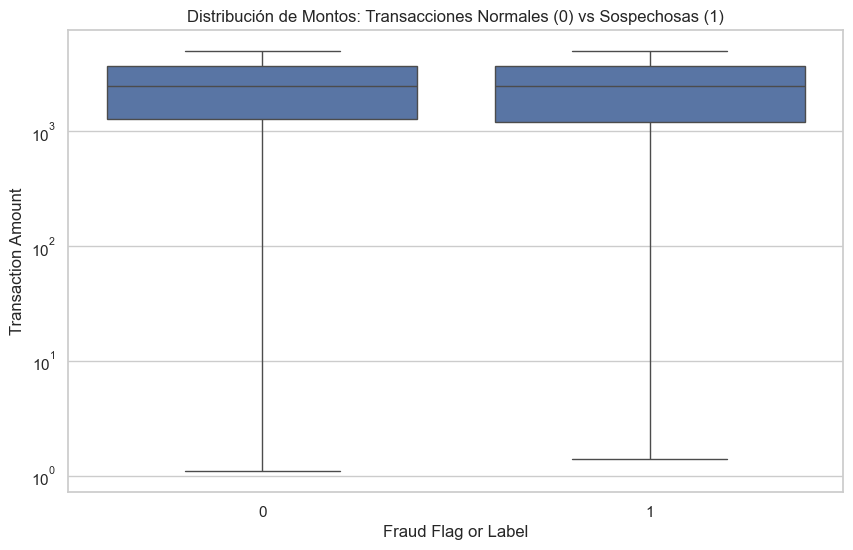

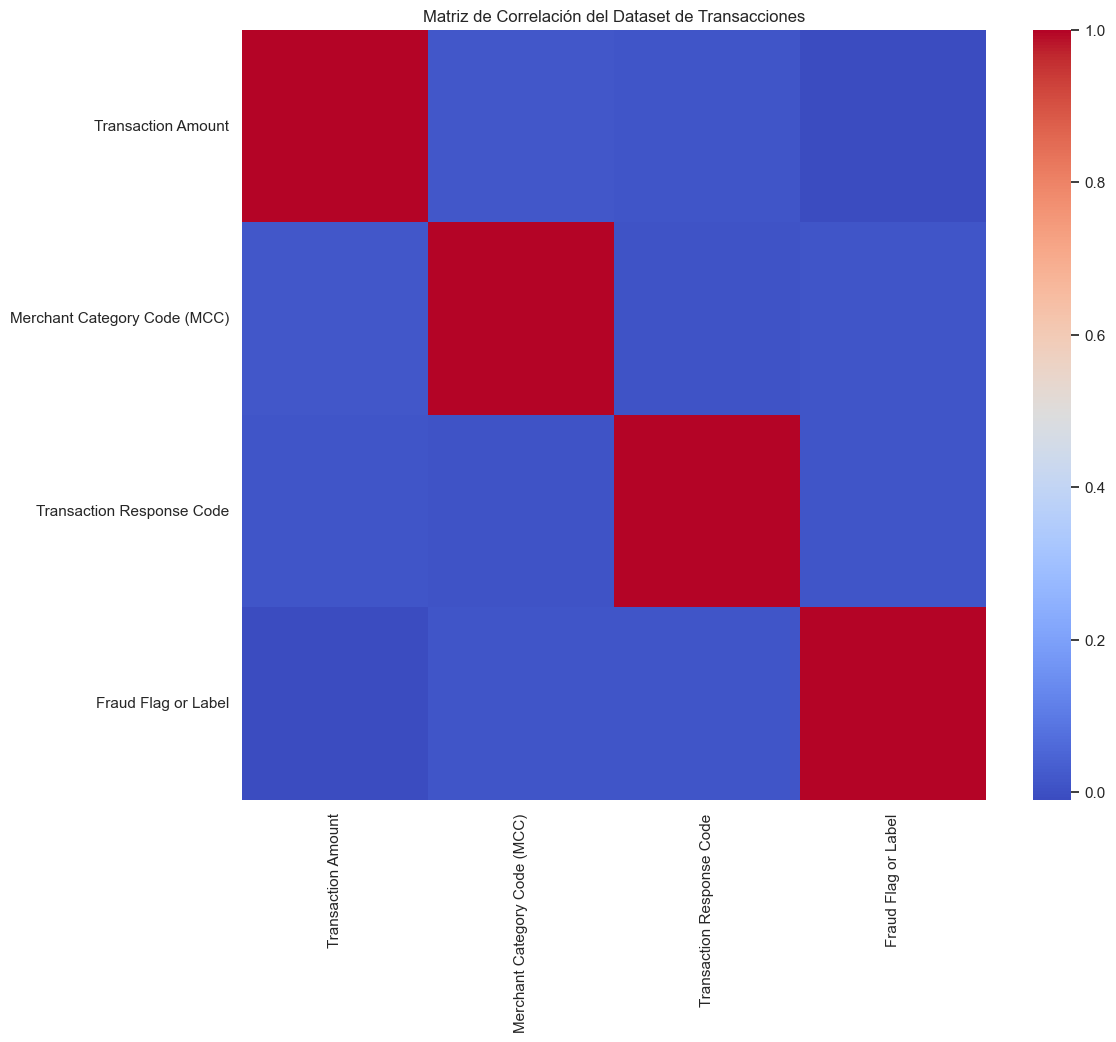

In [16]:
# Configuración del estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Visualización de la distribución de la variable Amount para fraude vs normal
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fraud Flag or Label', y='Transaction Amount', data=df)
plt.title('Distribución de Montos: Transacciones Normales (0) vs Sospechosas (1)')
plt.yscale('log')  # Escala logarítmica debido a la disparidad de montos
plt.show()

# Matriz de correlación lineal entre las variables numéricas principales
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include="number").corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Matriz de Correlación del Dataset de Transacciones')
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

# Verificar valores nulos en el DataFrame
total_nulos = df.isnull().sum().sum()
print(f"Cantidad total de valores nulos detectados antes de la limpieza: {total_nulos}")

# Eliminar filas con valores nulos de forma permanente si llegasen a existir
if total_nulos > 0:
    df = df.dropna()
    print("Se han eliminado exitosamente los registros que contenían valores nulos.")
else:
    print("El dataset no requiere remoción de filas; se encuentra completamente limpio.")

Cantidad total de valores nulos detectados antes de la limpieza: 0
El dataset no requiere remoción de filas; se encuentra completamente limpio.


In [21]:
# Aplicación y escalado
# Inicializar el objeto StandardScaler para el cálculo estadístico
escalador = StandardScaler()

# Mostrar los valores originales de las columnas antes de la transformación
print("\nValores originales antes del escalado (Primeros 5 registros):")
# Rename columns to match what the code expects
df = df.rename(columns={
    'Transaction Amount': 'Amount',
    'Transaction Date and Time': 'Time'
})

print(df[['Time', 'Amount']].head())

# Aplicar el ajuste y la transformación matemática a las columnas Time y Amount
df['Time'] = pd.to_datetime(df['Time']).astype(int) / 10**9
df[['Amount', 'Time']] = escalador.fit_transform(df[['Amount', 'Time']])


Valores originales antes del escalado (Primeros 5 registros):
        Time    Amount
5  -1.724857  0.615079
7   0.431078 -0.911940
8   0.695373 -1.412624
9   0.749651  1.420007
10 -1.480410 -0.439855


In [22]:
# Validacion de resultados del escalado
# Mostrar los nuevos valores escalados para confirmar el cambio visualmente
print("\nValores estandarizados después del escalado (Media 0, Desviación 1):")
print(df[['Time', 'Amount']].head())

# Verificar estadísticamente que la media sea aproximadamente 0 y la desviación estándar sea 1
print("\nComprobación estadística del escalado:")
print(f"Media de la columna Time: {df['Time'].mean():.2f}")
print(f"Desviación Estándar de la columna Time: {df['Time'].std():.2f}")
print(f"Media de la columna Amount: {df['Amount'].mean():.2f}")
print(f"Desviación Estándar de la columna Amount: {df['Amount'].std():.2f}")


Valores estandarizados después del escalado (Media 0, Desviación 1):
        Time    Amount
5  -1.527249  0.615079
7   0.014963 -0.911940
8   0.014963 -1.412624
9   0.014963  1.420007
10 -1.527249 -0.439855

Comprobación estadística del escalado:
Media de la columna Time: 0.00
Desviación Estándar de la columna Time: 1.00
Media de la columna Amount: -0.00
Desviación Estándar de la columna Amount: 1.00
